# Loan Approval Prediction
## Phase 4 – Exploratory Data Analysis

**Name:** Abdur Rafay Hassan Baloch  
**Dataset:** Cleaned Loan Approval Dataset  
**Target Variable:** Loan_Status

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_loan_approval_dataset.csv")

print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

df.head()

Dataset Shape: (614, 14)
Missing Values: 0
Duplicate Rows: 0


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,1


## 2. Statistical Summary

This section summarizes the main numerical features of the dataset.


In [2]:
summary_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Loan_Status"
]

print("Statistical Summary of Important Features:")
df[summary_columns].describe().round(2)

Statistical Summary of Important Features:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.00,614.00,614.00,614.00,614.00,614.00
mean,5403.46,1621.25,145.75,342.41,0.86,0.69
std,6109.04,2926.25,84.11,64.43,0.35,0.46
min,150.00,0.00,9.00,12.00,0.00,0.00
25%,2877.50,0.00,100.25,360.00,1.00,0.00
50%,3812.50,1188.50,128.00,360.00,1.00,1.00
75%,5795.00,2297.25,164.75,360.00,1.00,1.00
max,81000.00,41667.00,700.00,480.00,1.00,1.00


## 3. Loan Approval Distribution

This visualization compares the total number and percentage of approved and rejected loan applications.

Loan Approval Analysis:
Rejected Applications (0): 192 (31.27%)
Approved Applications (1): 422 (68.73%)


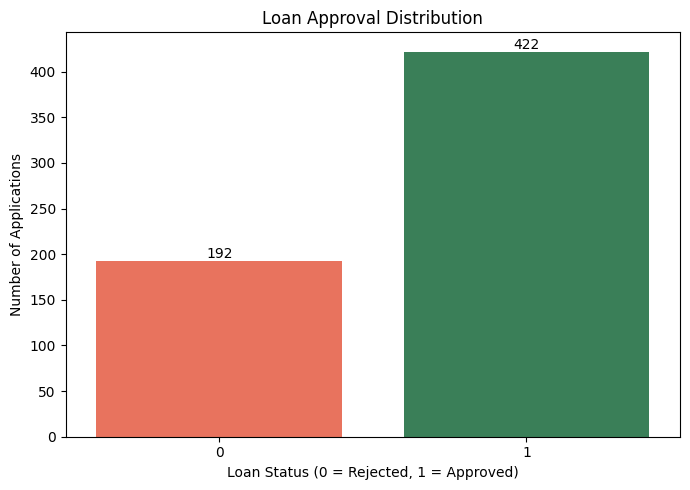

In [3]:
approval_counts = df["Loan_Status"].value_counts().sort_index()
approval_percentages = df["Loan_Status"].value_counts(
    normalize=True
).sort_index() * 100

print("Loan Approval Analysis:")
print(f"Rejected Applications (0): {approval_counts[0]} ({approval_percentages[0]:.2f}%)")
print(f"Approved Applications (1): {approval_counts[1]} ({approval_percentages[1]:.2f}%)")

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Loan_Status",
    hue="Loan_Status",
    palette={0: "tomato", 1: "seagreen"},
    legend=False
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Number of Applications")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 4. Credit History vs Loan Approval

This section analyzes the relationship between an applicant's credit history and loan approval.

Credit History and Loan Approval Analysis:
 Credit_History  Total_Applications  Approved_Applications  Approval_Rate
            0.0                  89                      7           7.87
            1.0                 525                    415          79.05


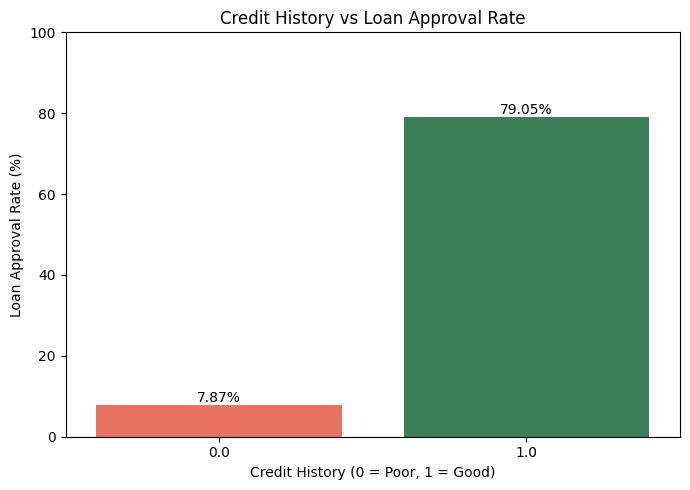

In [4]:
credit_summary = df.groupby("Credit_History").agg(
    Total_Applications=("Loan_Status", "count"),
    Approved_Applications=("Loan_Status", "sum"),
    Approval_Rate=("Loan_Status", "mean")
).reset_index()

credit_summary["Approval_Rate"] = (
    credit_summary["Approval_Rate"] * 100
).round(2)

print("Credit History and Loan Approval Analysis:")
print(credit_summary.to_string(index=False))

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=credit_summary,
    x="Credit_History",
    y="Approval_Rate",
    hue="Credit_History",
    palette={0.0: "tomato", 1.0: "seagreen"},
    legend=False
)

plt.title("Credit History vs Loan Approval Rate")
plt.xlabel("Credit History (0 = Poor, 1 = Good)")
plt.ylabel("Loan Approval Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

## 5. Applicant Income vs Loan Approval

This section compares applicant income for approved and rejected loan applications.

Applicant Income and Loan Approval Analysis:
             Applications  Mean_Income  Median_Income
Loan_Status                                          
0                     192      5446.08         3833.5
1                     422      5384.07         3812.5


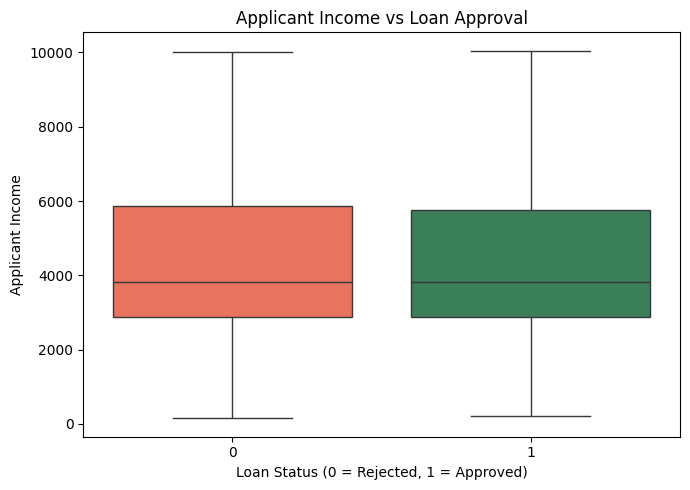

In [5]:
income_summary = df.groupby("Loan_Status")["ApplicantIncome"].agg(
    Applications="count",
    Mean_Income="mean",
    Median_Income="median"
).round(2)

print("Applicant Income and Loan Approval Analysis:")
print(income_summary)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome",
    hue="Loan_Status",
    palette={0: "tomato", 1: "seagreen"},
    legend=False,
    showfliers=False
)

plt.title("Applicant Income vs Loan Approval")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Applicant Income")
plt.tight_layout()
plt.show()

## 6. Loan Amount vs Loan Approval

This section analyzes the relationship between the requested loan amount and loan approval.

Loan Amount and Loan Approval Analysis:
             Applications  Mean_Loan_Amount  Median_Loan_Amount
Loan_Status                                                    
0                     192            149.89               128.0
1                     422            143.87               128.0


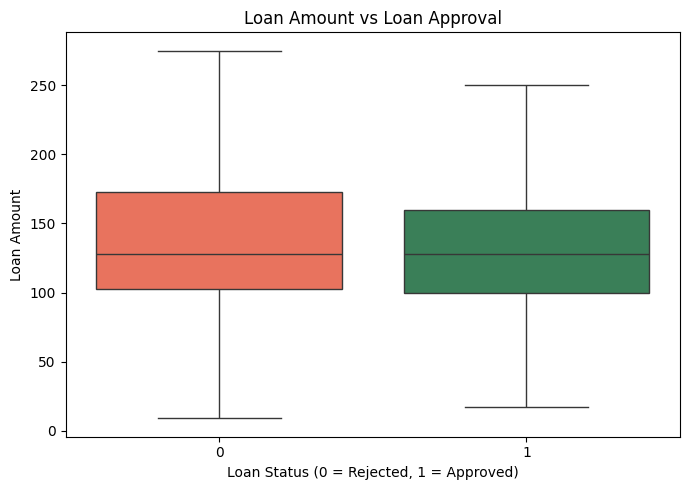

In [6]:
loan_amount_summary = df.groupby("Loan_Status")["LoanAmount"].agg(
    Applications="count",
    Mean_Loan_Amount="mean",
    Median_Loan_Amount="median"
).round(2)

print("Loan Amount and Loan Approval Analysis:")
print(loan_amount_summary)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="LoanAmount",
    hue="Loan_Status",
    palette={0: "tomato", 1: "seagreen"},
    legend=False,
    showfliers=False
)

plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

## 7. Education vs Loan Approval

This section compares loan approval rates for graduate and non-graduate applicants.


Education and Loan Approval Analysis:
Education_Level  Total_Applications  Approved_Applications  Approval_Rate
   Not Graduate                 134                     82          61.19
       Graduate                 480                    340          70.83


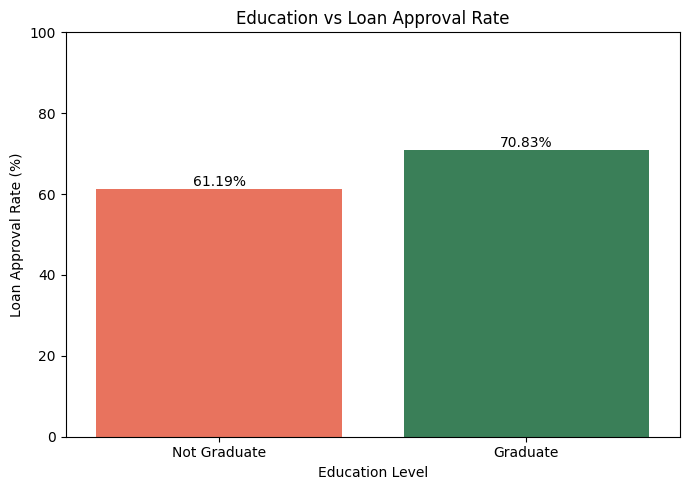

In [7]:
education_summary = df.groupby("Education").agg(
    Total_Applications=("Loan_Status", "count"),
    Approved_Applications=("Loan_Status", "sum"),
    Approval_Rate=("Loan_Status", "mean")
).reset_index()

education_summary["Approval_Rate"] = (
    education_summary["Approval_Rate"] * 100
).round(2)

education_summary["Education_Level"] = education_summary["Education"].map({
    0: "Not Graduate",
    1: "Graduate"
})

print("Education and Loan Approval Analysis:")
print(education_summary[
    ["Education_Level", "Total_Applications",
     "Approved_Applications", "Approval_Rate"]
].to_string(index=False))

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=education_summary,
    x="Education_Level",
    y="Approval_Rate",
    hue="Education_Level",
    palette=["tomato", "seagreen"],
    legend=False
)

plt.title("Education vs Loan Approval Rate")
plt.xlabel("Education Level")
plt.ylabel("Loan Approval Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

## 8. Employment vs Loan Approval

This section compares loan approval rates for self-employed and non-self-employed applicants.

Employment and Loan Approval Analysis:
Employment_Status  Total_Applications  Approved_Applications  Approval_Rate
Not Self-Employed                 532                    366          68.80
    Self-Employed                  82                     56          68.29


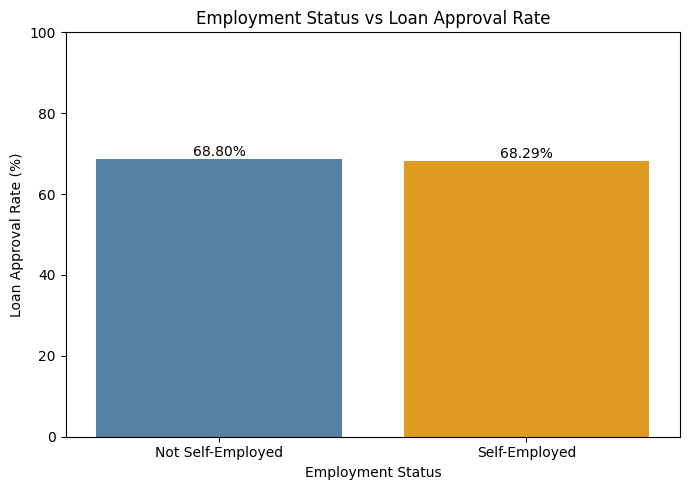

In [8]:
employment_summary = df.groupby("Self_Employed").agg(
    Total_Applications=("Loan_Status", "count"),
    Approved_Applications=("Loan_Status", "sum"),
    Approval_Rate=("Loan_Status", "mean")
).reset_index()

employment_summary["Approval_Rate"] = (
    employment_summary["Approval_Rate"] * 100
).round(2)

employment_summary["Employment_Status"] = employment_summary[
    "Self_Employed"
].map({
    0: "Not Self-Employed",
    1: "Self-Employed"
})

print("Employment and Loan Approval Analysis:")
print(employment_summary[
    ["Employment_Status", "Total_Applications",
     "Approved_Applications", "Approval_Rate"]
].to_string(index=False))

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=employment_summary,
    x="Employment_Status",
    y="Approval_Rate",
    hue="Employment_Status",
    palette=["steelblue", "orange"],
    legend=False
)

plt.title("Employment Status vs Loan Approval Rate")
plt.xlabel("Employment Status")
plt.ylabel("Loan Approval Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

A correlation heatmap is used to identify relationships between numerical features and loan approval.


Correlation of Features with Loan Status:
Loan_Status          1.000
Credit_History       0.541
Education            0.086
Self_Employed       -0.004
ApplicantIncome     -0.005
Loan_Amount_Term    -0.023
LoanAmount          -0.033
CoapplicantIncome   -0.059
Name: Loan_Status, dtype: float64


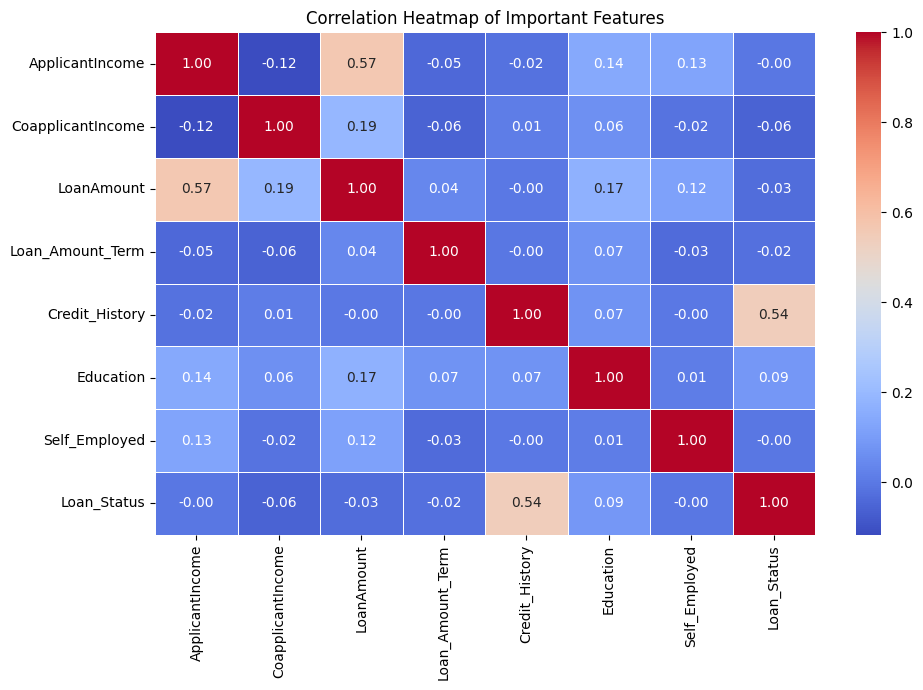

In [9]:
correlation_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Education",
    "Self_Employed",
    "Loan_Status"
]

correlation_matrix = df[correlation_columns].corr()

print("Correlation of Features with Loan Status:")
print(
    correlation_matrix["Loan_Status"]
    .sort_values(ascending=False)
    .round(3)
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Important Features")
plt.tight_layout()
plt.show()

## 10. Important Observations and Conclusion

The following observations summarize the main findings obtained from exploratory data analysis.

In [10]:
print("IMPORTANT EDA OBSERVATIONS")
print("-" * 50)
print("1. The dataset contains 614 applications and 14 features.")
print("2. There are no missing values or duplicate records.")
print("3. A total of 422 applications were approved and 192 were rejected.")
print("4. The overall loan approval rate is 68.73%.")
print("5. Credit history has the strongest relationship with loan approval.")
print("6. Applicants with good credit history have a much higher approval rate.")
print("7. Graduate applicants have a higher approval rate than non-graduates.")
print("8. Applicant income and loan amount alone do not determine approval.")
print("9. Employment status has a relatively weak relationship with approval.")
print("10. Credit history should be an important feature in model training.")

IMPORTANT EDA OBSERVATIONS
--------------------------------------------------
1. The dataset contains 614 applications and 14 features.
2. There are no missing values or duplicate records.
3. A total of 422 applications were approved and 192 were rejected.
4. The overall loan approval rate is 68.73%.
5. Credit history has the strongest relationship with loan approval.
6. Applicants with good credit history have a much higher approval rate.
7. Graduate applicants have a higher approval rate than non-graduates.
8. Applicant income and loan amount alone do not determine approval.
9. Employment status has a relatively weak relationship with approval.
10. Credit history should be an important feature in model training.
